# ✋ Hand Gesture Recognition — Transfer Learning with MobileNetV2

> **SkillCraft Technology | Machine Learning Internship — Task 04**

This notebook builds a complete, end-to-end deep learning pipeline that
recognizes hand gestures from images using **transfer learning**.

**Pipeline overview:**
1. Download the [LeapGestRecog dataset](https://www.kaggle.com/datasets/gti-upm/leapgestrecog) from Kaggle
2. Explore the dataset structure and class distribution
3. Build a labeled image dataframe and split into train / validation / test sets
4. Create data generators with augmentation, using MobileNetV2 preprocessing
5. Visualize sample gesture images
6. Build a **MobileNetV2** transfer-learning model (frozen base + custom classification head)
7. Train the model with callbacks (early stopping, learning-rate scheduling)
8. Plot training accuracy / loss curves
9. Evaluate on the test set and generate a confusion matrix
10. Visualize sample predictions with confidence scores
11. Save the trained model as `gesture_model.h5` for the Gradio app (`main.py`)

---


## Step 1 — Imports & Environment Setup

Import all the libraries needed for data handling, image processing,
model building (TensorFlow/Keras), and visualization.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.16.1
GPU available: []


## Step 2 — Download the LeapGestRecog Dataset

The dataset is downloaded directly from Kaggle using `kagglehub`. It contains
**20,000 near-infrared images** captured by a Leap Motion sensor across
**10 subjects** performing **10 distinct hand gestures**.

> 🔑 If running locally (not on Kaggle/Colab), make sure your Kaggle API
> credentials (`kaggle.json`) are configured, or that you are logged into
> `kagglehub`.


In [2]:
import kagglehub

# Downloads (or re-uses a cached copy of) the LeapGestRecog dataset
dataset_path = kagglehub.dataset_download("gti-upm/leapgestrecog")
print("Dataset downloaded to:", dataset_path)

# The dataset is nested - locate the actual 'leapGestRecog' root folder
for root, dirs, files in os.walk(dataset_path):
    if "leapGestRecog" in dirs:
        DATA_ROOT = os.path.join(root, "leapGestRecog")
        break
else:
    DATA_ROOT = dataset_path

print("Using data root:", DATA_ROOT)

Dataset downloaded to: C:\Users\sanuh\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1
Using data root: C:\Users\sanuh\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1\leapGestRecog


## Step 3 — Explore the Dataset Structure

The dataset is organized as:

```
leapGestRecog/
├── 00/                     <- subject 0
│   ├── 01_palm/            <- gesture class
│   │   ├── frame_00_01_0001.png
│   │   └── ...
│   ├── 02_l/
│   └── ... (10 gesture classes)
├── 01/                     <- subject 1
└── ... (10 subjects total)
```

Each of the 10 subjects performed each of the 10 gestures, giving
`10 subjects × 10 gestures × 200 images = 20,000 images` in total.


In [3]:
# Class names taken from the gesture sub-folder names (sorted)
CLASS_NAMES = sorted(os.listdir(os.path.join(DATA_ROOT, os.listdir(DATA_ROOT)[0])))
print("Detected gesture classes:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))

# Build a dataframe of (filepath, label) for every image in the dataset
filepaths, labels = [], []

for subject in sorted(os.listdir(DATA_ROOT)):
    subject_dir = os.path.join(DATA_ROOT, subject)
    if not os.path.isdir(subject_dir):
        continue
    for gesture in sorted(os.listdir(subject_dir)):
        gesture_dir = os.path.join(subject_dir, gesture)
        if not os.path.isdir(gesture_dir):
            continue
        for fname in os.listdir(gesture_dir):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                filepaths.append(os.path.join(gesture_dir, fname))
                labels.append(gesture)

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print("Total images found:", len(df))
print(df["label"].value_counts())

Detected gesture classes: ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']
Number of classes: 10
Total images found: 20000
label
01_palm          2000
02_l             2000
03_fist          2000
04_fist_moved    2000
05_thumb         2000
06_index         2000
07_ok            2000
08_palm_moved    2000
09_c             2000
10_down          2000
Name: count, dtype: int64


## Step 4 — Class Distribution

Visualize how many images belong to each gesture class to confirm the
dataset is balanced.


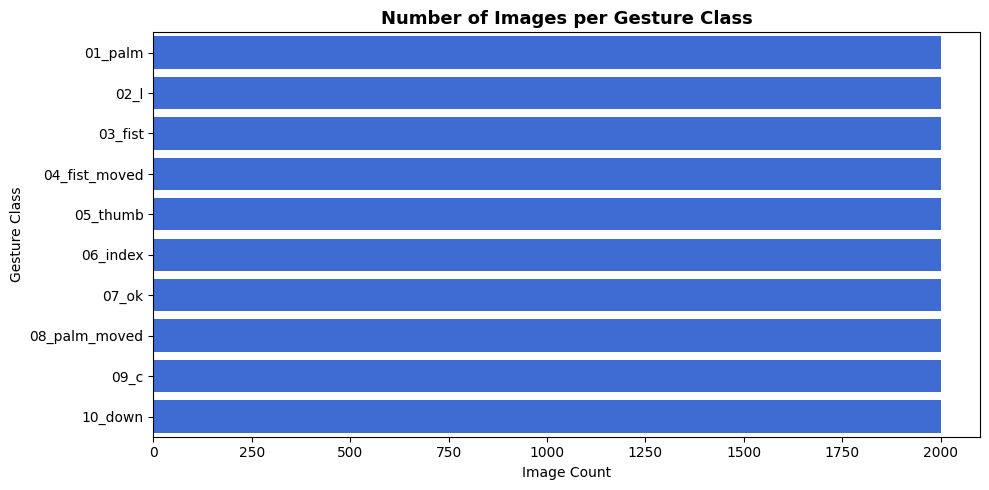

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="label", order=CLASS_NAMES, color="#2563eb")
plt.title("Number of Images per Gesture Class", fontsize=13, fontweight="bold")
plt.xlabel("Image Count")
plt.ylabel("Gesture Class")
plt.tight_layout()
plt.show()

## Step 5 — Train / Validation / Test Split

Split the dataframe into:
- **70%** training
- **15%** validation
- **15%** test

The split is **stratified** by gesture label to preserve class balance,
and uses a fixed random seed for reproducibility.


In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Training samples:  ", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:      ", len(test_df))

Training samples:   14000
Validation samples: 3000
Test samples:       3000


## Step 6 — Data Generators (with Augmentation)

Images are loaded in batches using `ImageDataGenerator`:

- **Resized** to `224 x 224` (required input size for MobileNetV2)
- **Converted to RGB** (the source images are grayscale near-infrared frames,
  so they are stacked into 3 channels)
- **Preprocessed** using MobileNetV2's `preprocess_input`, which scales pixel
  values to the `[-1, 1]` range expected by the pretrained backbone
- **Augmented** (training set only) with small rotations, zoom, width/height
  shifts and brightness changes to improve generalization

> Note: horizontal flipping is intentionally **disabled** because some
> gestures (e.g. directional / moved gestures) are not symmetric.


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(CLASS_NAMES)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.8, 1.2),
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, color_mode="rgb",
    class_mode="categorical", classes=CLASS_NAMES,
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED,
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, color_mode="rgb",
    class_mode="categorical", classes=CLASS_NAMES,
    batch_size=BATCH_SIZE, shuffle=False,
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, color_mode="rgb",
    class_mode="categorical", classes=CLASS_NAMES,
    batch_size=BATCH_SIZE, shuffle=False,
)

Found 14000 validated image filenames belonging to 10 classes.
Found 3000 validated image filenames belonging to 10 classes.
Found 3000 validated image filenames belonging to 10 classes.


## Step 7 — Visualize Sample Gesture Images

Display a grid of sample images from the training set, one (or more) per
gesture class, to verify the data pipeline is working correctly.


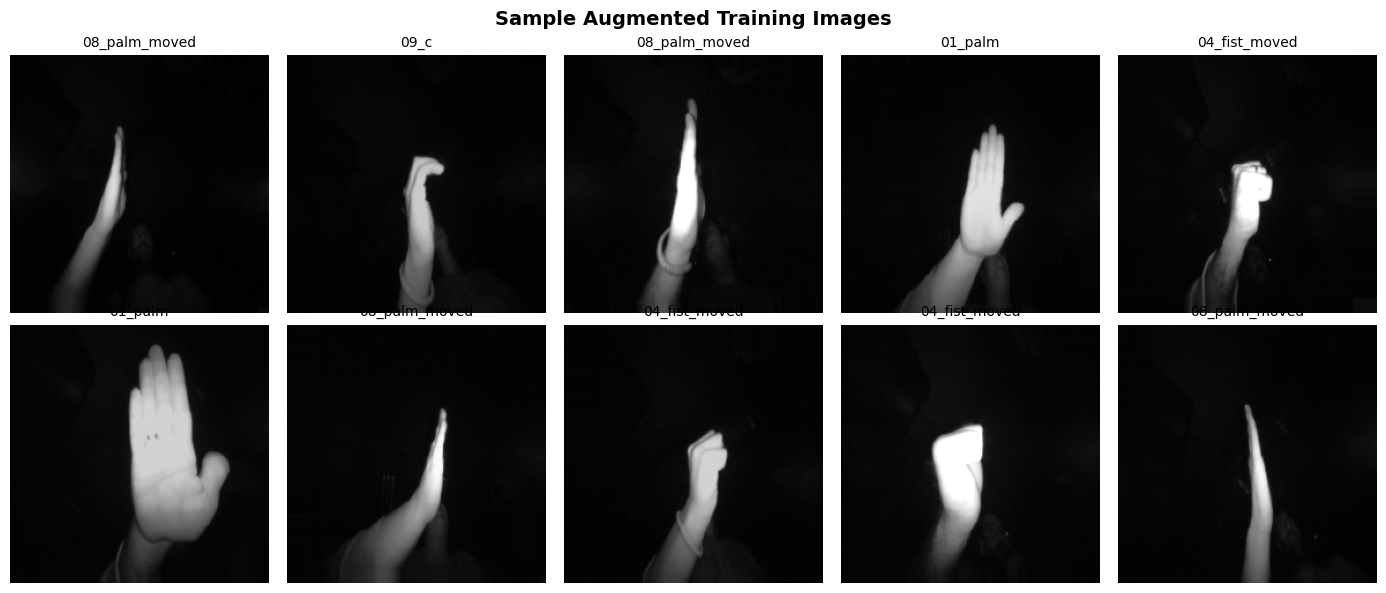

In [7]:
sample_batch, sample_labels = next(train_generator)

plt.figure(figsize=(14, 6))
for i in range(min(10, len(sample_batch))):
    plt.subplot(2, 5, i + 1)
    # Undo MobileNetV2 preprocessing for display: [-1,1] -> [0,1]
    img = (sample_batch[i] + 1) / 2.0
    plt.imshow(img)
    class_idx = np.argmax(sample_labels[i])
    plt.title(CLASS_NAMES[class_idx], fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Augmented Training Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 8 — Build the Transfer Learning Model (MobileNetV2)

We use **MobileNetV2** pretrained on ImageNet as a frozen feature extractor,
and attach a custom classification head:

```
Input (224x224x3)
   │
   ▼
MobileNetV2 base (frozen, ImageNet weights)
   │
   ▼
GlobalAveragePooling2D
   │
   ▼
Dense(256, relu) → Dropout(0.3)
   │
   ▼
Dense(128, relu) → Dropout(0.2)
   │
   ▼
Dense(10, softmax)   <- gesture class probabilities
```

Freezing the base layers means MobileNetV2's pretrained convolutional
filters (edges, textures, shapes learned from ImageNet) are reused as-is,
and **only the new dense layers are trained** — this drastically reduces
training time and the amount of data required.


In [8]:
# Load MobileNetV2 without its original classification head
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze all base layers so their pretrained weights are not updated
base_model.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
output_layer = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output_layer, name="GestureMobileNetV2")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "GestureMobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,620,106 (9.99 MB)

 Trainable params: 362,122 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 9 — Train the Model

The model is trained for up to **15 epochs** with the following callbacks:

- **EarlyStopping**: stops training if validation loss stops improving
  (restores the best weights)
- **ReduceLROnPlateau**: reduces the learning rate when validation loss
  plateaus
- **ModelCheckpoint**: saves the best-performing model during training


In [10]:
os.makedirs("saved_model", exist_ok=True)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint(
        filepath="saved_model/gesture_model_best.h5",
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

EPOCHS = 2

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/2
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9726 - loss: 0.0855

438/438 ━━━━━━━━━━━━━━━━━━━━ 637s 1s/step - accuracy: 0.9794 - loss: 0.0646 - val_accuracy: 0.9937 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 2/2
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9839 - loss: 0.0456

438/438 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - accuracy: 0.9871 - loss: 0.0391 - val_accuracy: 0.9983 - val_loss: 0.0076 - learning_rate: 0.0010


## Step 10 — Training Curves (Accuracy & Loss)

Plot the training and validation accuracy / loss across epochs and save the
figures to the `outputs/` directory for the README and reports.


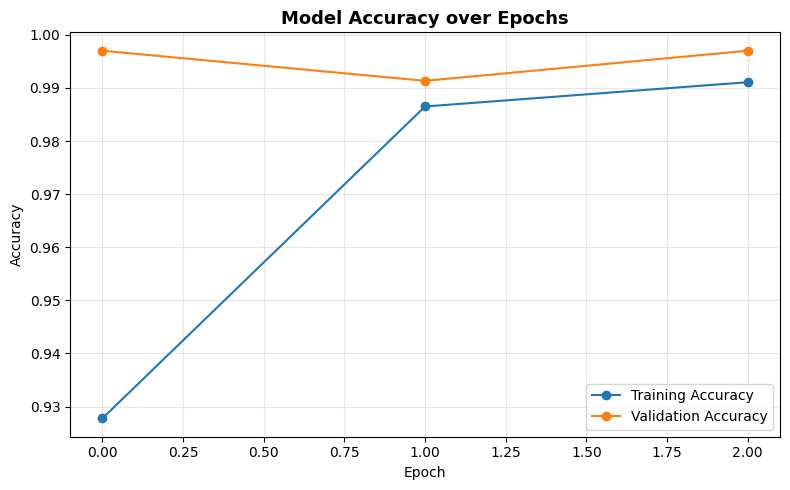

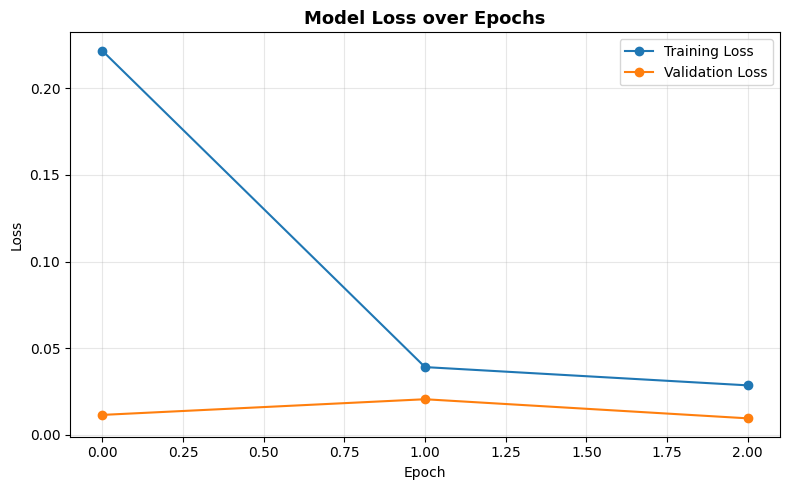

In [ ]:
os.makedirs("outputs", exist_ok=True)

# --- Accuracy curve ---
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy", marker="o")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", marker="o")
plt.title("Model Accuracy over Epochs", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Loss curve ---
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss", marker="o")
plt.plot(history.history["val_loss"], label="Validation Loss", marker="o")
plt.title("Model Loss over Epochs", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 11 — Evaluate on the Test Set

Evaluate the trained model on the held-out test set and print a full
classification report (precision, recall, F1-score per class).


In [11]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Predictions for the full test set
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 458ms/step - accuracy: 0.9987 - loss: 0.0071
Test Loss:     0.0071
Test Accuracy: 99.87%
94/94 ━━━━━━━━━━━━━━━━━━━━ 47s 479ms/step

Classification Report:

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       300
         02_l       0.99      1.00      1.00       300
      03_fist       1.00      1.00      1.00       300
04_fist_moved       1.00      1.00      1.00       300
     05_thumb       1.00      1.00      1.00       300
     06_index       1.00      0.99      0.99       300
        07_ok       1.00      1.00      1.00       300
08_palm_moved       1.00      1.00      1.00       300
         09_c       1.00      1.00      1.00       300
      10_down       1.00      1.00      1.00       300

     accuracy                           1.00      3000
    macro avg       1.00      1.00      1.00      3000
 weighted avg       1.00      1.00      1.00      3000



## Step 12 — Confusion Matrix

Visualize the confusion matrix as a heatmap to see how well the model
distinguishes between each pair of gesture classes.


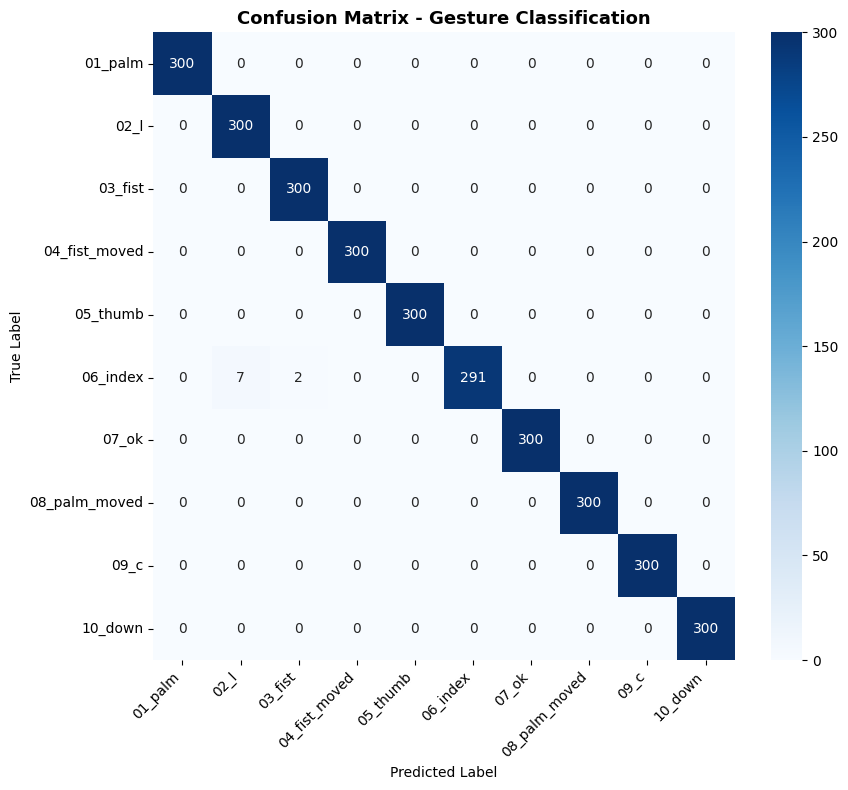

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
)
plt.title("Confusion Matrix - Gesture Classification", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 13 — Sample Predictions with Confidence Scores

Display a grid of test images with their **true label**, **predicted
label**, and the model's **confidence percentage**. Correct predictions are
highlighted in green and incorrect ones in red.


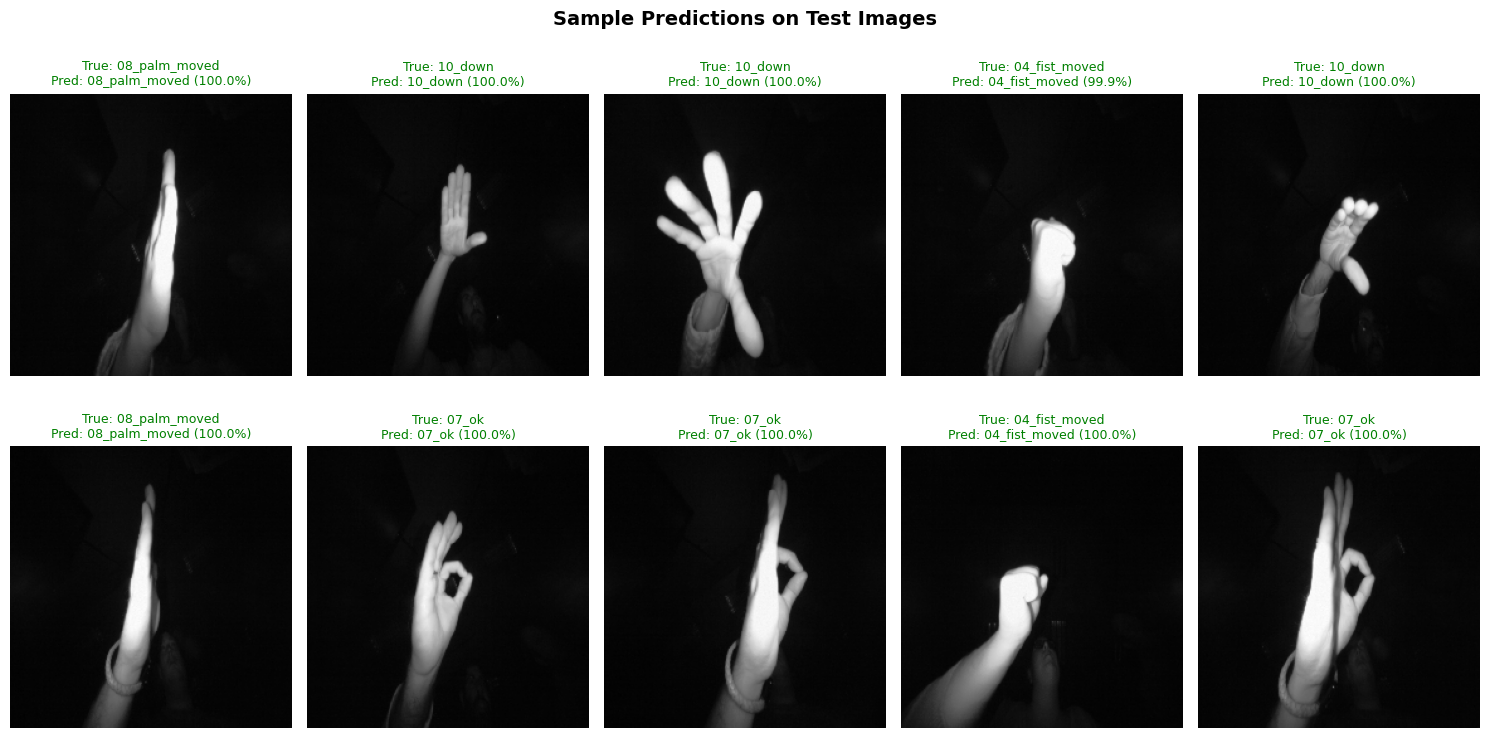

In [ ]:
test_df_reset = test_df.reset_index(drop=True)

plt.figure(figsize=(15, 8))
sample_indices = random.sample(range(len(test_df_reset)), 10)

for plot_idx, idx in enumerate(sample_indices):
    img_path = test_df_reset.loc[idx, "filepath"]
    true_label = test_df_reset.loc[idx, "label"]

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_label = CLASS_NAMES[pred_idx]
    confidence = pred_probs[pred_idx] * 100

    plt.subplot(2, 5, plot_idx + 1)
    plt.imshow(img)
    color = "green" if pred_label == true_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
              fontsize=9, color=color)
    plt.axis("off")

plt.suptitle("Sample Predictions on Test Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/prediction_examples.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 14 — Save the Final Model

Save the trained model in HDF5 (`.h5`) format inside `saved_model/`. This is
the exact file loaded by the Gradio application (`main.py`).


In [14]:
model.save("saved_model/gesture_model.h5")
print("Model saved to saved_model/gesture_model.h5")

Model saved to saved_model/gesture_model.h5


## ✅ Summary

- Loaded and explored the **LeapGestRecog** dataset (20,000 images, 10 gesture classes)
- Built a stratified 70/15/15 train/validation/test split
- Applied **transfer learning** with a **frozen MobileNetV2** backbone + a
  custom dense classification head
- Trained with early stopping and learning-rate scheduling
- Evaluated performance using accuracy, a classification report, and a
  confusion matrix
- Saved all visualizations to `outputs/` and the final model to
  `saved_model/gesture_model.h5`

The saved model is now ready to be served through the **Gradio** web
application defined in `main.py`. 🚀
